In [ ]:
# library(ArchR)
# addArchRGenome("mm10")
# library(BSgenome.Mmusculus.UCSC.mm10)

# proj <- loadArchRProject(path = "data/snATAC_data/ArchRProject")
# proj <- addUMAP(ArchRProj = proj, reducedDims = "Harmony", name = "UMAPHarmony", nNeighbors = 15, minDist = 0.8, metric = "cosine", force=TRUE)
# umap_coords <- getEmbedding(proj, embedding = "UMAPHarmony")
# metadata <- as.data.frame(getCellColData(proj))
# write.csv(umap_coords, "data/snATAC_data/archr_umap.csv")
# write.csv(metadata, "data/snATAC_data/archr_metadata.csv")

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
umap_df = pd.read_csv("data/snATAC_data/archr_umap.csv", index_col=0)
meta_df = pd.read_csv("data/snATAC_data/archr_metadata.csv", index_col=0)

In [3]:
adata = sc.AnnData(X=np.zeros((meta_df.shape[0], 1)), obs=meta_df)

In [4]:
adata.obsm['X_umap'] = umap_df.loc[adata.obs_names].values

In [7]:
adata.uns['Celltype_colors'] = ['#4b95b7','#bb2232','#4c9942','#bee097','#c7b3d3','#ef9ba7','#9a6ab0','#df8139','#b5d0d9']

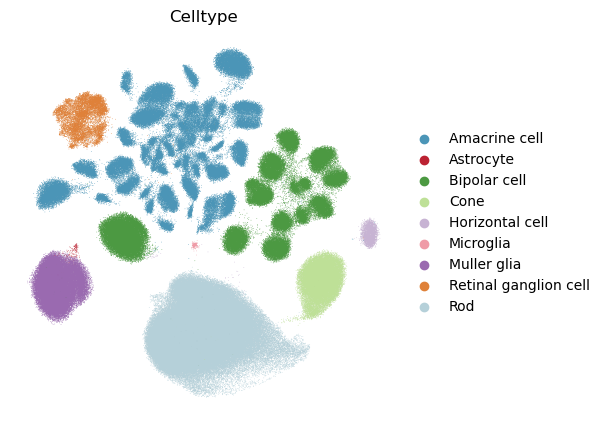

In [8]:
with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(adata, color=['Celltype'], frameon=False, size=1, alpha=1)